In [1]:
# TITANIC DATASET - BIAS AND CLASS IMBALANCE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# 1. Load and Explore the Dataset
df = pd.read_csv("train.csv")
print("First 5 rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [3]:
# 2. Check Data Quality
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows:
0

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [4]:
# 3. Identify the Target Variable
target = "Survived"
print("\nTarget Variable:", target)


Target Variable: Survived


In [5]:
# 4. Analyze Class Distribution
print("\nSurvival Class Distribution:")
print(df[target].value_counts())
print("\nSurvival Percentage:")
print(df[target].value_counts(normalize=True) * 100)


Survival Class Distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


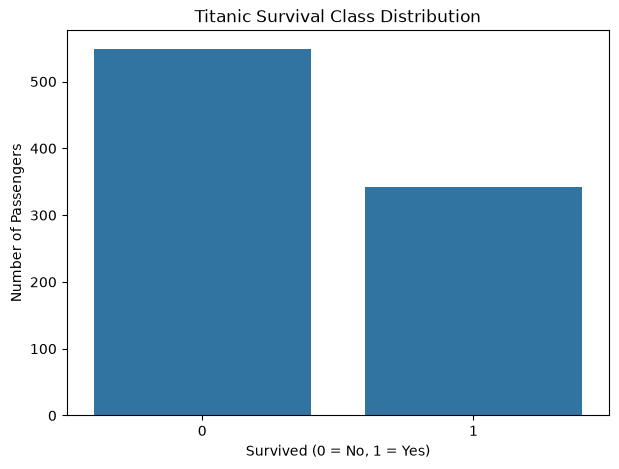

In [6]:
# 5. Visualize Class Imbalance
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Survived")
plt.title("Titanic Survival Class Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


Gender Representation:
Sex
male      577
female    314
Name: count, dtype: int64


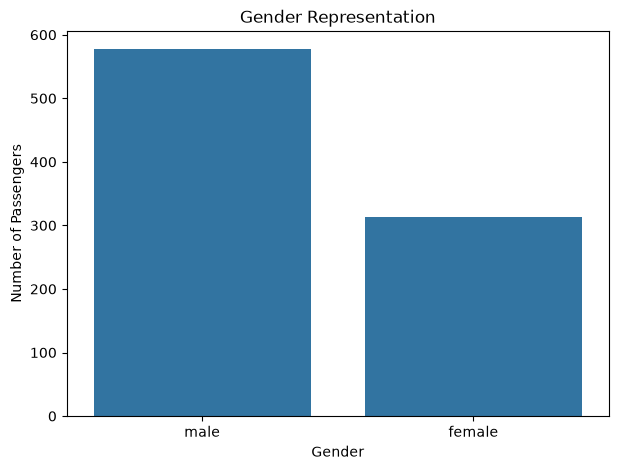

In [8]:
# 6. Analyze Gender Representation
print("\nGender Representation:")
print(df["Sex"].value_counts())
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex")
plt.title("Gender Representation")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()


Survival by Gender:
Survived    0    1
Sex               
female     81  233
male      468  109


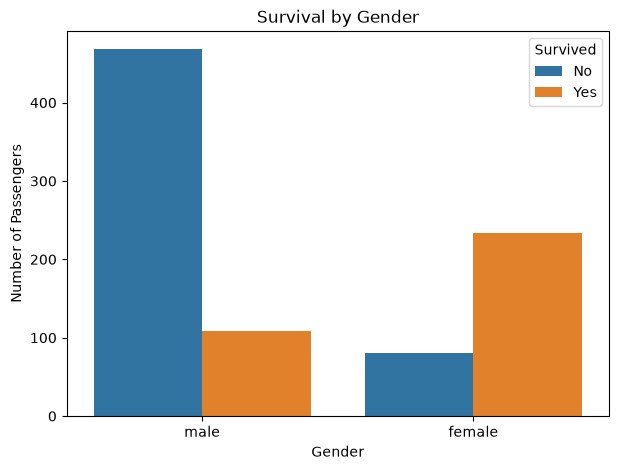

In [9]:
# 7. Analyze Survival by Gender
print("\nSurvival by Gender:")
print(pd.crosstab(df["Sex"], df["Survived"]))
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()


Passenger Class Representation:
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


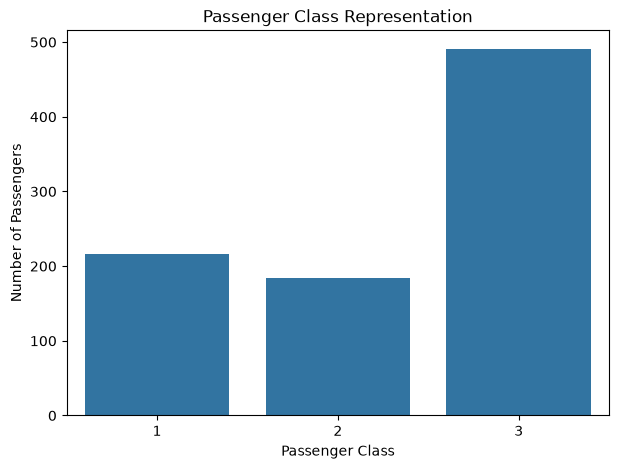

In [10]:
# 8. Analyze Passenger-Class Representation
print("\nPassenger Class Representation:")
print(df["Pclass"].value_counts().sort_index())
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Pclass")
plt.title("Passenger Class Representation")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()


Survival by Passenger Class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


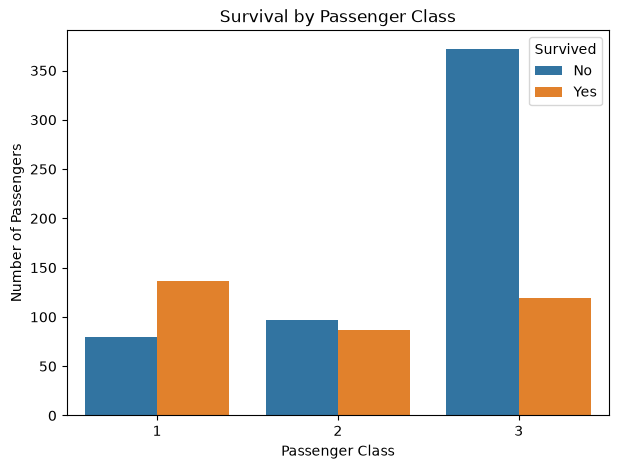

In [11]:
# 9. Analyze Survival by Passenger Class
print("\nSurvival by Passenger Class:")
print(pd.crosstab(df["Pclass"], df["Survived"]))
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

In [12]:
# 10. Analyze Age Groups
# Create age groups
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
print("\nAge Group Distribution:")
print(df["Age_Group"].value_counts().sort_index())


Age Group Distribution:
Age_Group
Child           69
Teenager        70
Young Adult    358
Adult          195
Senior          22
Name: count, dtype: int64



Survival by Age Group:
Survived       0    1
Age_Group            
Child         29   40
Teenager      40   30
Young Adult  221  137
Adult        117   78
Senior        17    5


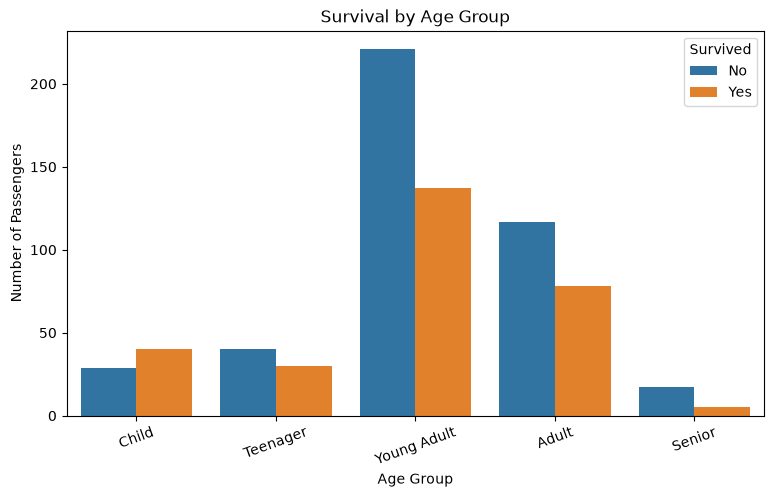

In [13]:
# 11. Analyze Survival by Age Group
print("\nSurvival by Age Group:")
print(pd.crosstab(df["Age_Group"], df["Survived"]))
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Age_Group", hue="Survived")
plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=20)
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

In [14]:
# 12. Identify Possible Bias
print("\nPossible Bias:")
print("""
1. Survival rates differ significantly between males and females.
2. First-class passengers had better survival chances than lower classes.
3. Some age groups may have different survival rates.
4. Missing age values can reduce the accuracy of age-based analysis.
5. The dataset may not represent the entire population equally.
""")


Possible Bias:

1. Survival rates differ significantly between males and females.
2. First-class passengers had better survival chances than lower classes.
3. Some age groups may have different survival rates.
4. Missing age values can reduce the accuracy of age-based analysis.
5. The dataset may not represent the entire population equally.



QUESTION 2

In [15]:
# GERMAN CREDIT RISK DATASET
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# 1. Load and Explore the Dataset
df = pd.read_csv("german_credit_data.csv")
print("First 5 rows:")
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe(include="all"))

First 5 rows:
   Unnamed: 0  Age     Sex  Job Housing Saving accounts Checking account  \
0           0   67    male    2     own             NaN           little   
1           1   22  female    2     own          little         moderate   
2           2   49    male    1     own          little              NaN   
3           3   45    male    2    free          little           little   
4           4   53    male    2    free          little           little   

   Credit amount  Duration              Purpose  Risk  
0           1169         6             radio/TV  good  
1           5951        48             radio/TV   bad  
2           2096        12            education  good  
3           7882        42  furniture/equipment  good  
4           4870        24                  car   bad  

Dataset Shape:
(1000, 11)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
--- 

In [17]:
# 2. Check Data Quality
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())
print("\nData Types:")
print(df.dtypes)


Missing Values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Duplicate Rows:
0

Data Types:
Unnamed: 0          int64
Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object


In [18]:
# Identify actual column names
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']


In [19]:
# 3. Identify Target Variable
target = "Risk"
print("\nTarget Variable:", target)


Target Variable: Risk


In [20]:
# 4. Analyze Class Distribution
print("\nCredit Risk Class Distribution:")
print(df[target].value_counts())

print("\nCredit Risk Percentage:")
print(df[target].value_counts(normalize=True) * 100)


Credit Risk Class Distribution:
Risk
good    700
bad     300
Name: count, dtype: int64

Credit Risk Percentage:
Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64


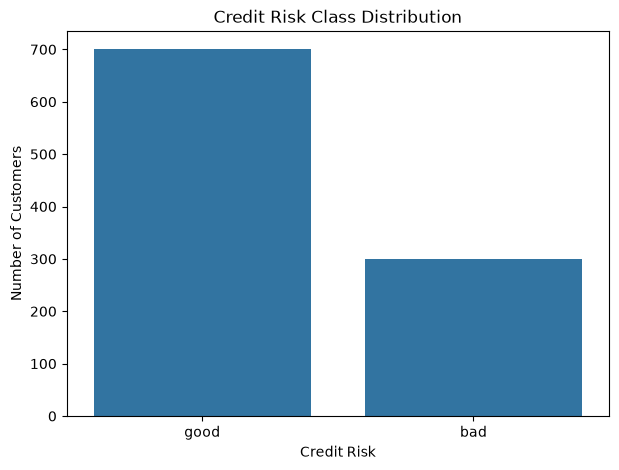

In [21]:
# 5. Visualize Class Imbalance
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x=target)
plt.title("Credit Risk Class Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.show()


Gender Representation:
Sex
male      690
female    310
Name: count, dtype: int64


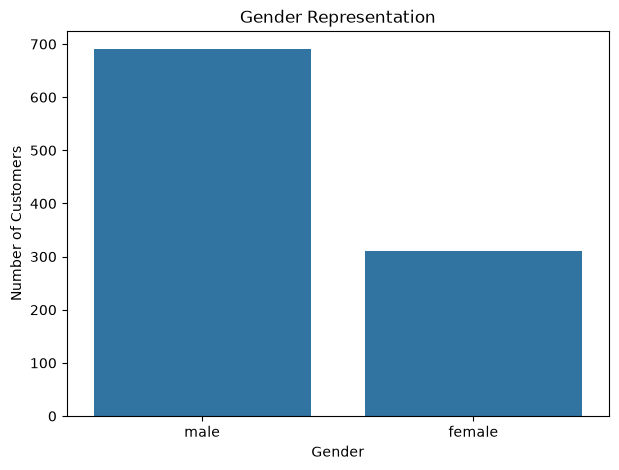

In [22]:
# 6. Analyze Gender Representation
print("\nGender Representation:")
print(df["Sex"].value_counts())
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex")
plt.title("Gender Representation")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


Credit Risk by Gender:
Risk    bad  good
Sex              
female  109   201
male    191   499


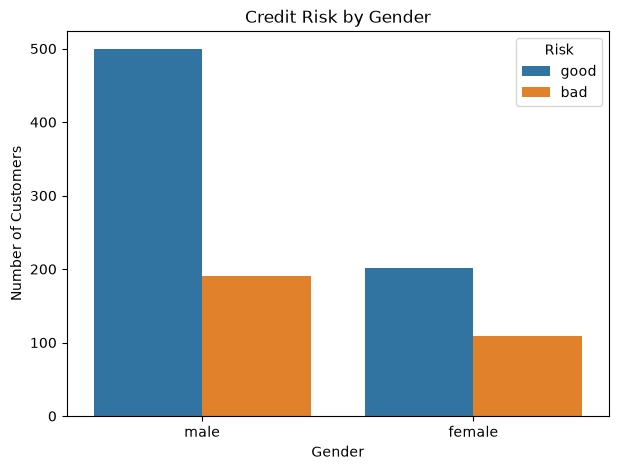

In [23]:
# 7. Analyze Credit Risk by Gender
print("\nCredit Risk by Gender:")
print(pd.crosstab(df["Sex"], df["Risk"]))
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="Risk")
plt.title("Credit Risk by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


Age Group Distribution:
Age_Group
Young (≤25)            190
Adult (26-35)          398
Middle Age (36-50)     299
Older Adult (51-65)     95
Senior (66+)            18
Name: count, dtype: int64


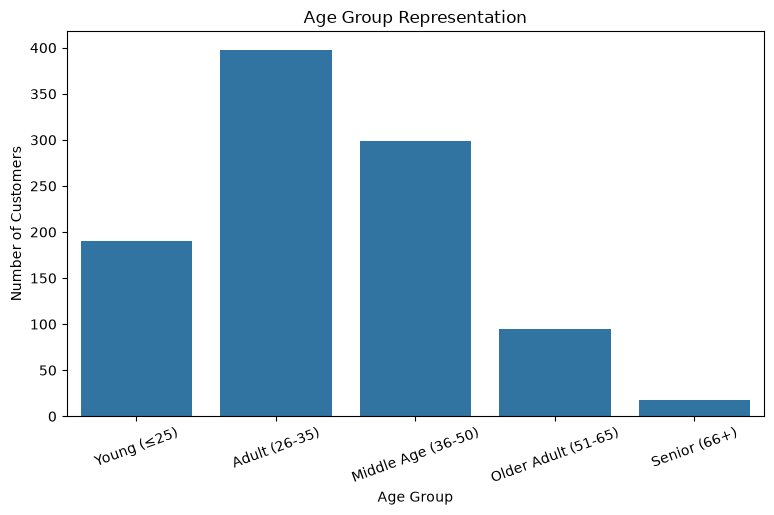

In [24]:
# 8. Analyze Age Groups
bins = [0, 25, 35, 50, 65, 100]
labels = [
    "Young (≤25)",
    "Adult (26-35)",
    "Middle Age (36-50)",
    "Older Adult (51-65)",
    "Senior (66+)"
]
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels,
    include_lowest=True
)
print("\nAge Group Distribution:")
print(df["Age_Group"].value_counts().sort_index())
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Age_Group")
plt.title("Age Group Representation")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()


Credit Risk by Age Group:
Risk                 bad  good
Age_Group                     
Young (≤25)           80   110
Adult (26-35)        118   280
Middle Age (36-50)    71   228
Older Adult (51-65)   26    69
Senior (66+)           5    13


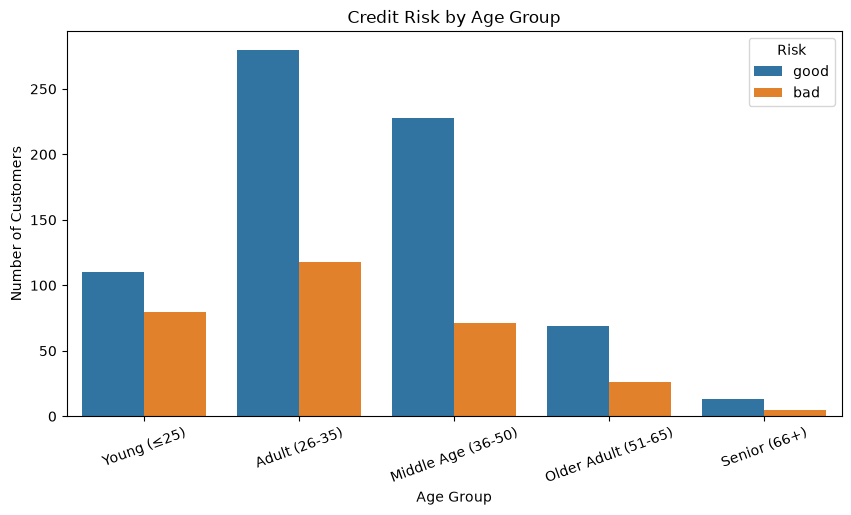

In [25]:
# 9. Analyze Credit Risk by Age Group
print("\nCredit Risk by Age Group:")
print(pd.crosstab(df["Age_Group"], df["Risk"]))
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="Age_Group", hue="Risk")
plt.title("Credit Risk by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()


Housing Category Representation:
Housing
own     713
rent    179
free    108
Name: count, dtype: int64


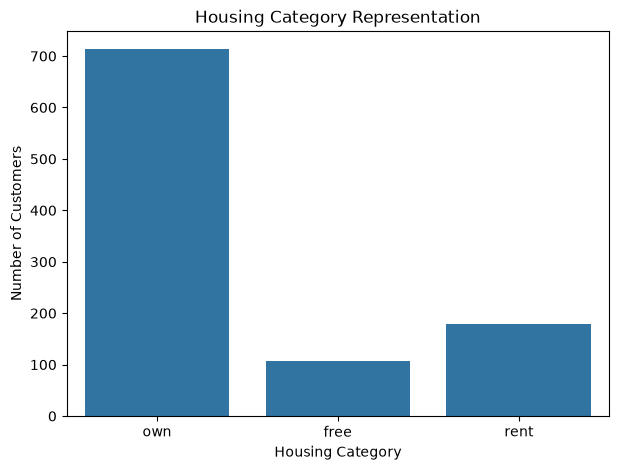

In [26]:
# 10. Analyze Housing Category Representation
print("\nHousing Category Representation:")
print(df["Housing"].value_counts())
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Housing")
plt.title("Housing Category Representation")
plt.xlabel("Housing Category")
plt.ylabel("Number of Customers")
plt.show()


Credit Risk by Housing Category:
Risk     bad  good
Housing           
free      44    64
own      186   527
rent      70   109


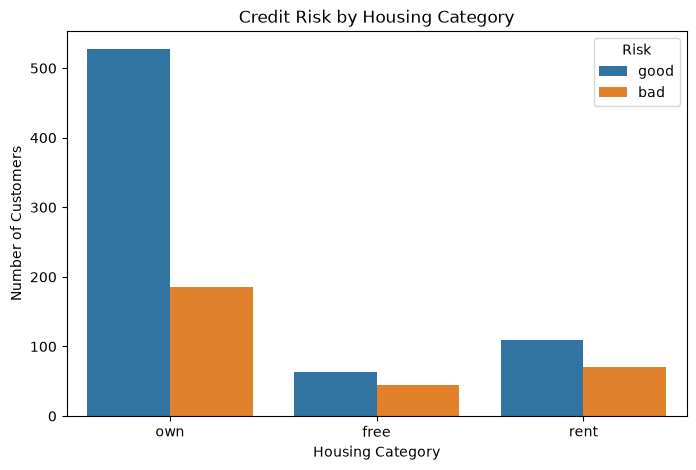

In [27]:
# 11. Analyze Credit Risk by Housing Category
print("\nCredit Risk by Housing Category:")
print(pd.crosstab(df["Housing"], df["Risk"]))
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Housing", hue="Risk")
plt.title("Credit Risk by Housing Category")
plt.xlabel("Housing Category")
plt.ylabel("Number of Customers")
plt.show()


In [30]:
# 12. Identify Possible Bias
print("\nPossible Bias:")
print("""
1. The distribution of customers may not be equal across genders.
2. Credit risk may differ between males and females.
3. Different age groups may have different risk levels.
4. Housing category may be associated with credit risk.
5. Historical lending decisions may contain social or economic biases.
6. Missing values can affect the quality of the analysis.
""")


Possible Bias:

1. The distribution of customers may not be equal across genders.
2. Credit risk may differ between males and females.
3. Different age groups may have different risk levels.
4. Housing category may be associated with credit risk.
5. Historical lending decisions may contain social or economic biases.
6. Missing values can affect the quality of the analysis.

